# ResNet Checkpoint Analysis
Loads all `.pt` checkpoints from a parent directory, extracts training history, and produces a ranking with mean ± std across seeds.


In [9]:
import os
import re
from pathlib import Path
from collections import defaultdict

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')


## Configuration


In [10]:
CHECKPOINTS_ROOT = Path("../checkpoints_ResNets")  # change if needed
DEVICE = torch.device("cpu")  # checkpoints are loaded for history only, no GPU needed

# Folder name pattern: checkpoints_ResNets_{SEED}
SEED_FOLDER_PATTERN = re.compile(r"checkpoints_ResNets_(\d+)$")


## 1. Scan and Load Checkpoints


In [11]:
def load_checkpoint(pt_path: Path, device=DEVICE) -> dict | None:
    try:
        try:
            ckpt = torch.load(pt_path, map_location=device, weights_only=True)
        except Exception:
            # Fall back for checkpoints that contain non-tensor objects
            ckpt = torch.load(pt_path, map_location=device, weights_only=False)

        return {
            "history":      ckpt.get("history",      None),
            "accuracy":     ckpt.get("accuracy",     None),
            "top5_accuracy":ckpt.get("top5_accuracy",None),
            "f1_macro":     ckpt.get("f1_macro",     None),
            "f1_weighted":  ckpt.get("f1_weighted",  None),
        }

    except Exception as e:
        print(f"  [WARN] Could not load {pt_path.name}: {e}")
        return None


# Structure: records[run_name][seed] = ckpt_data
records: dict[str, dict[int, dict]] = defaultdict(dict)

for folder in sorted(CHECKPOINTS_ROOT.iterdir()):
    if not folder.is_dir():
        continue
    m = SEED_FOLDER_PATTERN.match(folder.name)
    if not m:
        continue
    seed = int(m.group(1))

    for pt_file in sorted(folder.glob("*.pt")):
        run_name = pt_file.stem  # e.g. pretrained_resnet50_ce_adam
        ckpt_data = load_checkpoint(pt_file)
        if ckpt_data is not None and ckpt_data["history"] is not None:
            records[run_name][seed] = ckpt_data

print(f"Total unique runs found: {len(records)}")


Total unique runs found: 20


## 2. Extract Best-Epoch Metrics per Seed


In [12]:
def best_metrics(ckpt_data: dict) -> dict:
    history = ckpt_data["history"]
    val_losses = np.asarray(history["val_loss"])
    best_epoch = int(np.argmin(val_losses))

    return {
        "best_val_loss":   float(val_losses[best_epoch]),
        "best_val_acc":    float(history["val_acc"][best_epoch]),
        "best_train_acc":  float(history["train_acc"][best_epoch]),
        "best_train_loss": float(history["train_loss"][best_epoch]),
        "best_epoch":      best_epoch + 1,
        "total_epochs":    len(val_losses),
        "accuracy":        ckpt_data["accuracy"],
        "top5_accuracy":   ckpt_data["top5_accuracy"],
        "f1_macro":        ckpt_data["f1_macro"],
        "f1_weighted":     ckpt_data["f1_weighted"],
    }


rows = []
for run_name, seed_dict in records.items():
    for seed, ckpt_data in seed_dict.items():
        m = best_metrics(ckpt_data)
        rows.append({"run": run_name, "seed": seed, **m})

df_raw = pd.DataFrame(rows)
print(df_raw.to_string(index=False))


                                                                       run  seed  best_val_loss  best_val_acc  best_train_acc  best_train_loss  best_epoch  total_epochs  accuracy  top5_accuracy  f1_macro  f1_weighted
                                                   custom_resnet18_ce_adam     0       1.244688      0.875000        0.954556         1.048600          39            40       NaN       0.971154  0.873852     0.873050
                                                   custom_resnet18_ce_adam     1       1.192833      0.892308        0.948786         1.061882          39            40       NaN       0.977885  0.892169     0.891766
                                                   custom_resnet18_ce_adam  1010       1.199816      0.886538        0.951190         1.058217          38            40       NaN       0.975000  0.886128     0.885710
                                                   custom_resnet18_ce_adam  2026       1.215109      0.886538        0.955518       

## 3. Aggregate: Mean and Std Across Seeds


In [13]:
agg_metrics = [
    "best_val_acc", "best_val_loss",
    "best_train_acc", "best_train_loss",
    "best_epoch", "total_epochs",
    "accuracy", "top5_accuracy",
    "f1_macro", "f1_weighted",
]

grouped = df_raw.groupby("run")[agg_metrics]
df_mean  = grouped.mean().add_suffix("_mean")
df_std   = grouped.std(ddof=1).add_suffix("_std").fillna(0.0)
df_count = df_raw.groupby("run").size().rename("n_seeds")

df_agg = pd.concat([df_count, df_mean, df_std], axis=1).reset_index()
df_agg = df_agg.sort_values("best_val_acc_mean", ascending=False).reset_index(drop=True)
df_agg.index += 1
df_agg.index.name = "rank"

display_cols = [
    "run", "n_seeds",
    "best_val_acc_mean", "best_val_acc_std",
    "best_val_loss_mean", "best_val_loss_std",
    "best_train_acc_mean", "best_train_acc_std",
    "total_epochs_mean",
]

print("=== Ranking (sorted by val_acc mean, descending) ===")
print(df_agg[display_cols].to_string())


=== Ranking (sorted by val_acc mean, descending) ===
                                                                             run  n_seeds  best_val_acc_mean  best_val_acc_std  best_val_loss_mean  best_val_loss_std  best_train_acc_mean  best_train_acc_std  total_epochs_mean
rank                                                                                                                                                                                                                             
1                                                    pretrained_resnet50_ce_adam        5           0.949808          0.010002            0.937867           0.029095             0.995720            0.002971               30.4
2     pretrained_resnet50_ce_adam_bs16_lr5e-05_wd0.001-bs-16-lr5e-05-wdecay0.001        5           0.948269          0.006283            0.947834           0.023549             0.991104            0.005368               26.8
3                                          

## 4. Formatted Ranking Table


In [17]:
def fmt(mean, std) -> str:
    return f"{mean:.4f} +/- {std:.4f}"


df_pretty = df_agg[["run", "n_seeds"]].copy()
df_pretty["val_acc"]     = df_agg.apply(lambda r: fmt(r["best_val_acc_mean"],    r["best_val_acc_std"]),    axis=1)
df_pretty["val_loss"]    = df_agg.apply(lambda r: fmt(r["best_val_loss_mean"],   r["best_val_loss_std"]),   axis=1)
df_pretty["train_acc"]   = df_agg.apply(lambda r: fmt(r["best_train_acc_mean"],  r["best_train_acc_std"]),  axis=1)
df_pretty["top5_acc"]    = df_agg.apply(lambda r: fmt(r["top5_accuracy_mean"],   r["top5_accuracy_std"]),   axis=1)
df_pretty["f1_macro"]    = df_agg.apply(lambda r: fmt(r["f1_macro_mean"],        r["f1_macro_std"]),        axis=1)
df_pretty["f1_weighted"] = df_agg.apply(lambda r: fmt(r["f1_weighted_mean"],     r["f1_weighted_std"]),     axis=1)
df_pretty["epochs"]      = df_agg["total_epochs_mean"].round(1)

print(df_pretty.to_string())


                                                                             run  n_seeds            val_acc           val_loss          train_acc           top5_acc           f1_macro        f1_weighted  epochs
rank                                                                                                                                                                                                               
1                                                    pretrained_resnet50_ce_adam        5  0.9498 +/- 0.0100  0.9379 +/- 0.0291  0.9957 +/- 0.0030  0.9892 +/- 0.0047  0.9499 +/- 0.0105  0.9497 +/- 0.0103    30.4
2     pretrained_resnet50_ce_adam_bs16_lr5e-05_wd0.001-bs-16-lr5e-05-wdecay0.001        5  0.9483 +/- 0.0063  0.9478 +/- 0.0235  0.9911 +/- 0.0054  0.9910 +/- 0.0036  0.9470 +/- 0.0071  0.9468 +/- 0.0069    26.8
3                                                    pretrained_resnet18_ce_adam        5  0.9462 +/- 0.0086  0.9830 +/- 0.0204  0.9968 +/- 0.0008  0.99

## 5. Ranking Bar Chart (val_acc mean +/- std)


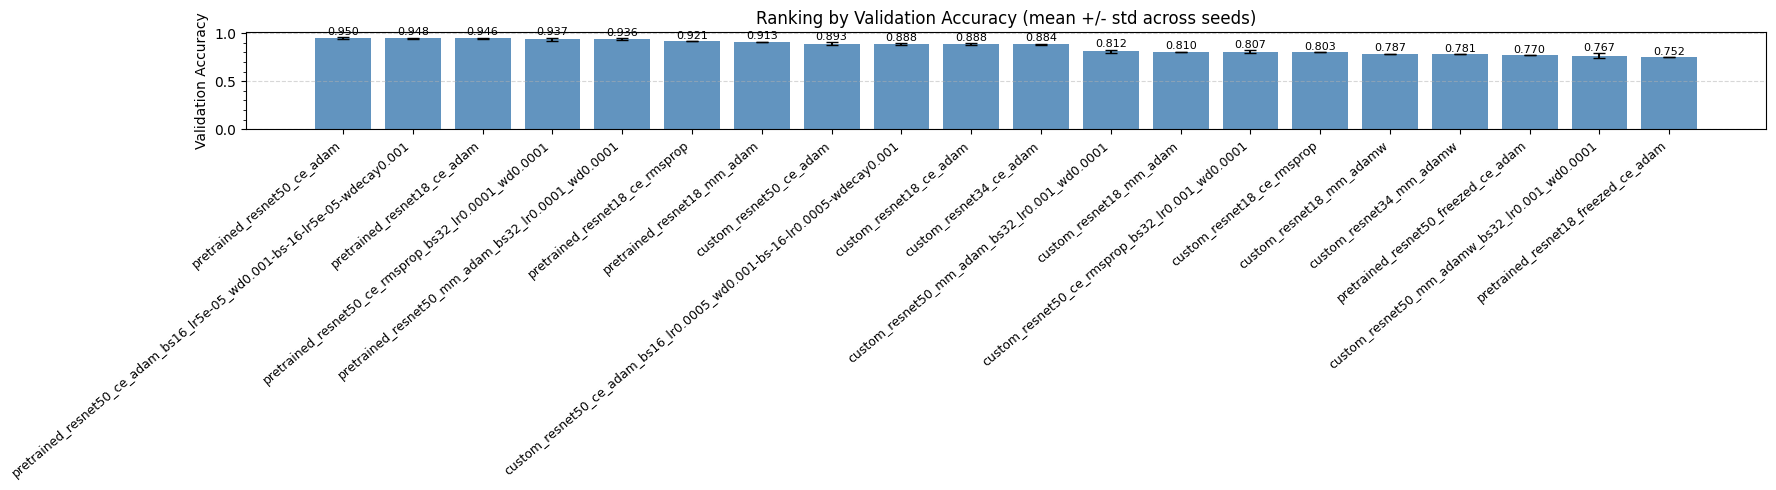

In [15]:
runs  = df_agg["run"].tolist()
means = df_agg["best_val_acc_mean"].to_numpy()
stds  = df_agg["best_val_acc_std"].to_numpy()
x     = np.arange(len(runs))

fig, ax = plt.subplots(figsize=(max(10, len(df_agg) * 0.9), 5))

bars = ax.bar(
    x, means, yerr=stds,
    capsize=4, color="steelblue", alpha=0.85,
    ecolor="black", linewidth=0.8,
)

for bar, mean, std in zip(bars, means, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        mean + std + 0.003,
        f"{mean:.3f}",
        ha="center", va="bottom", fontsize=8,
    )

ax.set_xticks(x)
ax.set_xticklabels(runs, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("Validation Accuracy")
ax.set_title("Ranking by Validation Accuracy (mean +/- std across seeds)")
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="y", linestyle="--", alpha=0.5)

upper = float((means + stds).max()) if len(means) > 0 else 1.0
ax.set_ylim(0, min(1.05, upper + 0.05))

plt.tight_layout()
plt.show()


## 6. Learning Curves per Run (all seeds overlaid)


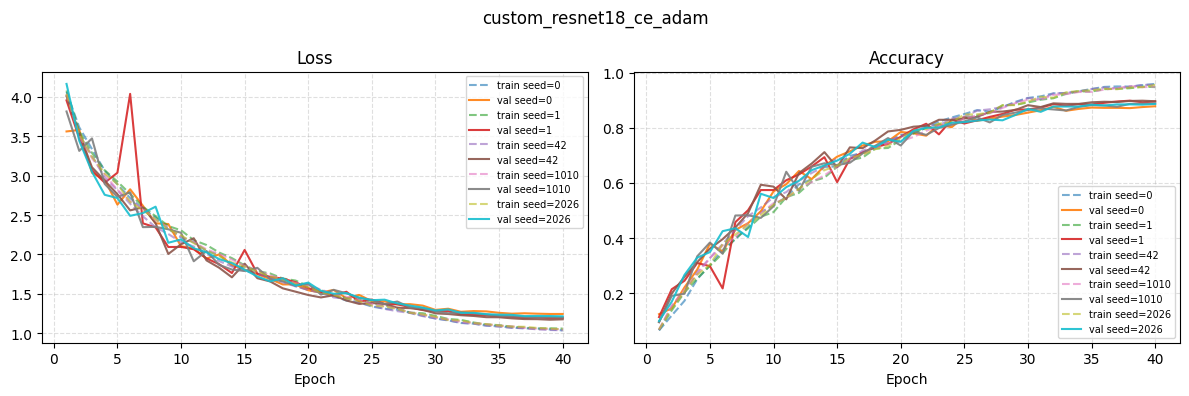

Saved: ../checkpoints_ResNets/figures/custom_resnet18_ce_adam_curves.png


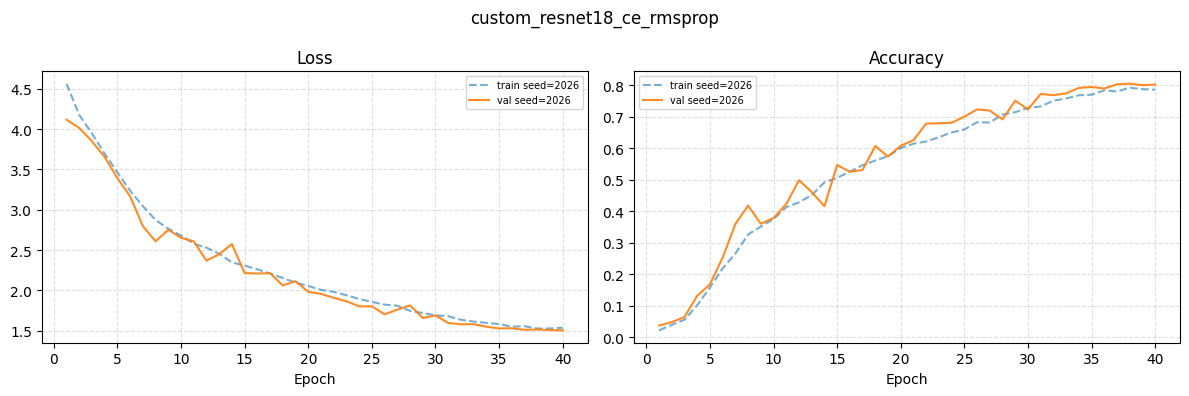

Saved: ../checkpoints_ResNets/figures/custom_resnet18_ce_rmsprop_curves.png


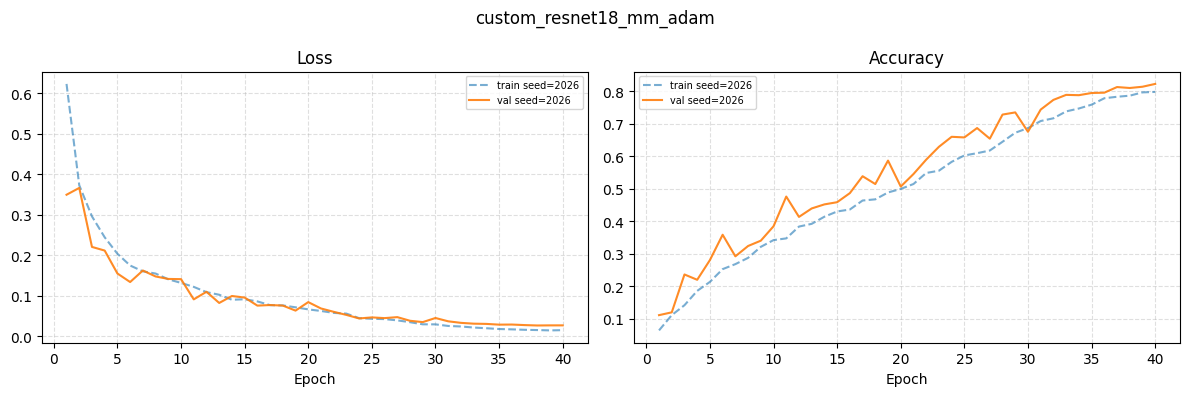

Saved: ../checkpoints_ResNets/figures/custom_resnet18_mm_adam_curves.png


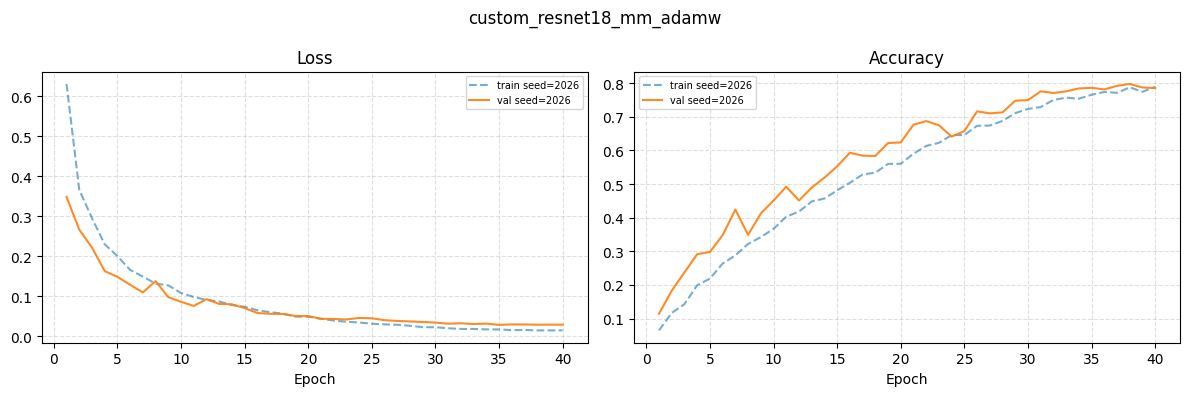

Saved: ../checkpoints_ResNets/figures/custom_resnet18_mm_adamw_curves.png


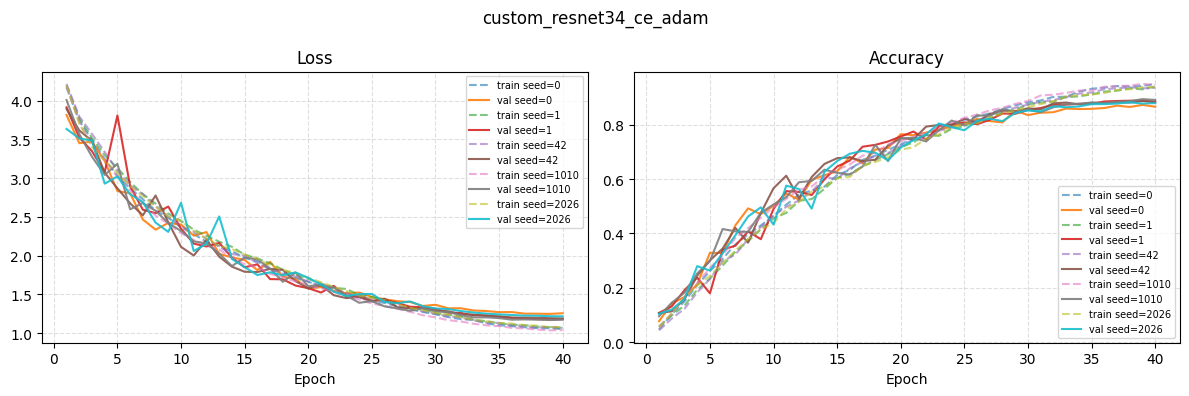

Saved: ../checkpoints_ResNets/figures/custom_resnet34_ce_adam_curves.png


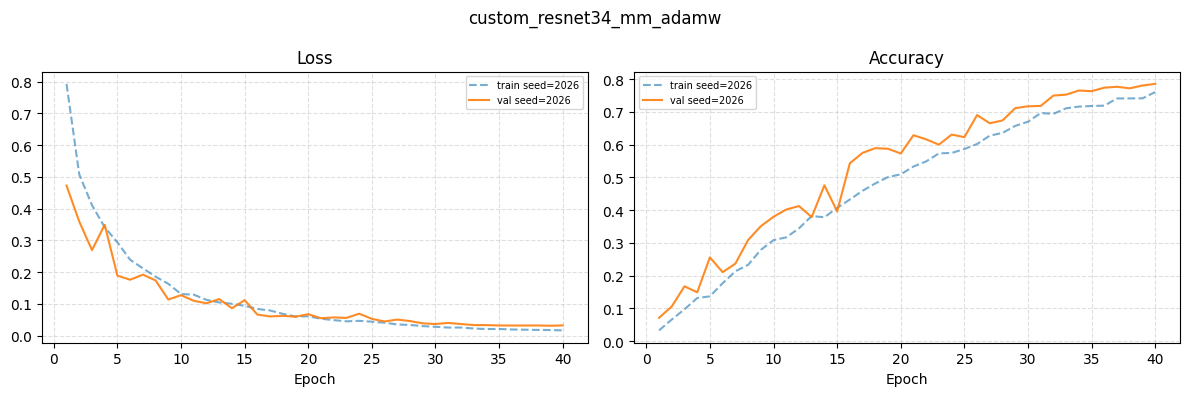

Saved: ../checkpoints_ResNets/figures/custom_resnet34_mm_adamw_curves.png


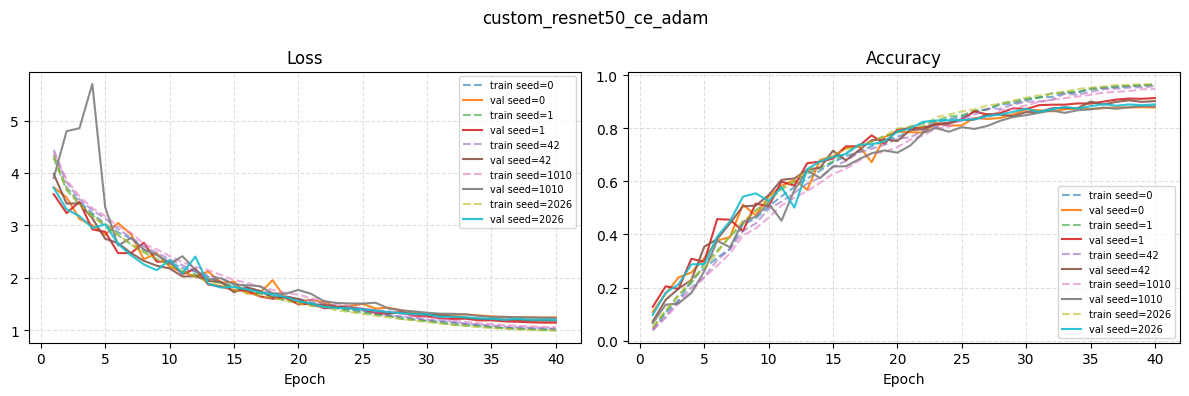

Saved: ../checkpoints_ResNets/figures/custom_resnet50_ce_adam_curves.png


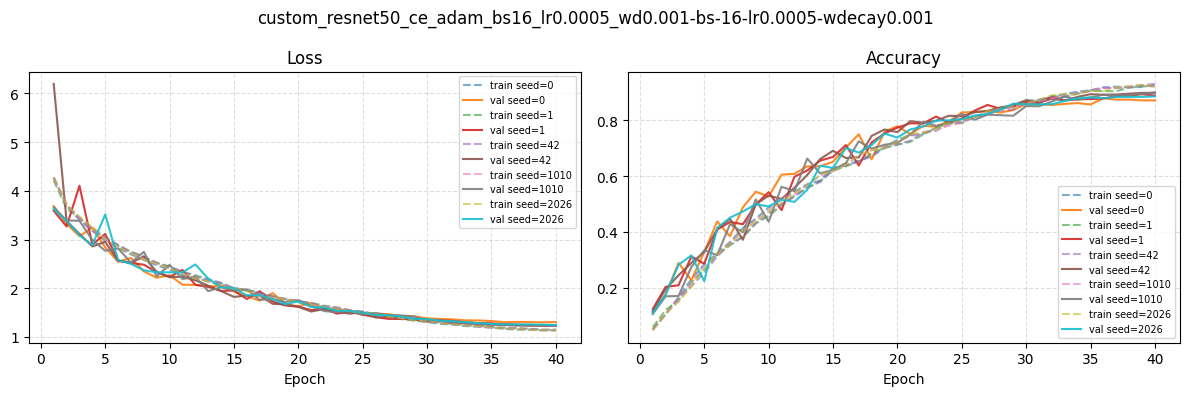

Saved: ../checkpoints_ResNets/figures/custom_resnet50_ce_adam_bs16_lr0.0005_wd0.001-bs-16-lr0.0005-wdecay0.001_curves.png


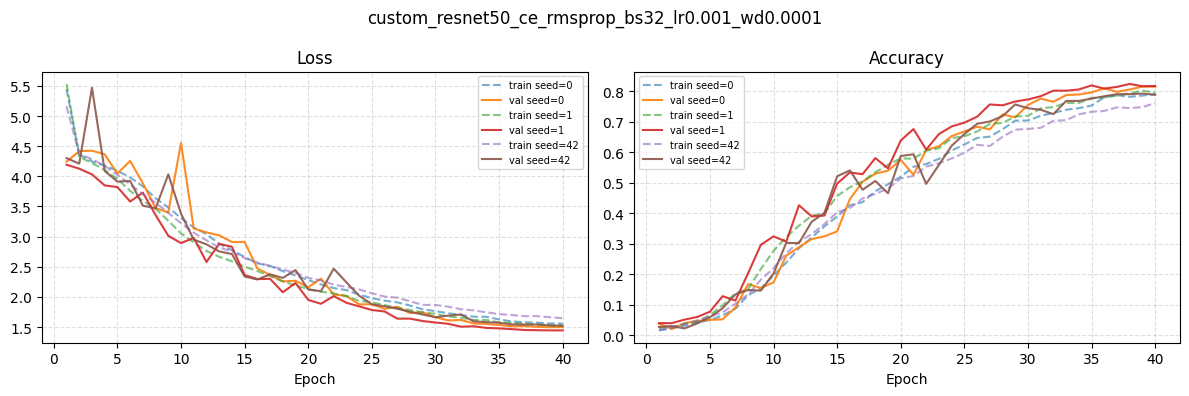

Saved: ../checkpoints_ResNets/figures/custom_resnet50_ce_rmsprop_bs32_lr0.001_wd0.0001_curves.png


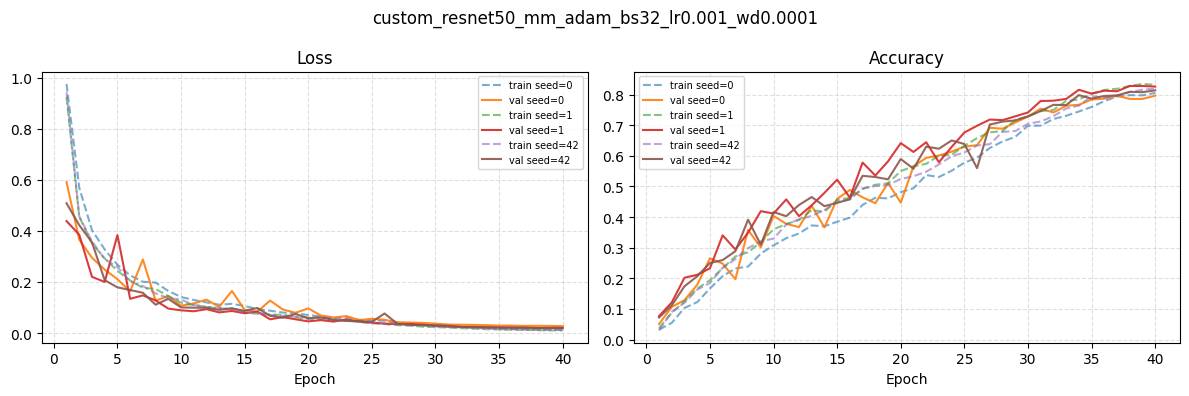

Saved: ../checkpoints_ResNets/figures/custom_resnet50_mm_adam_bs32_lr0.001_wd0.0001_curves.png


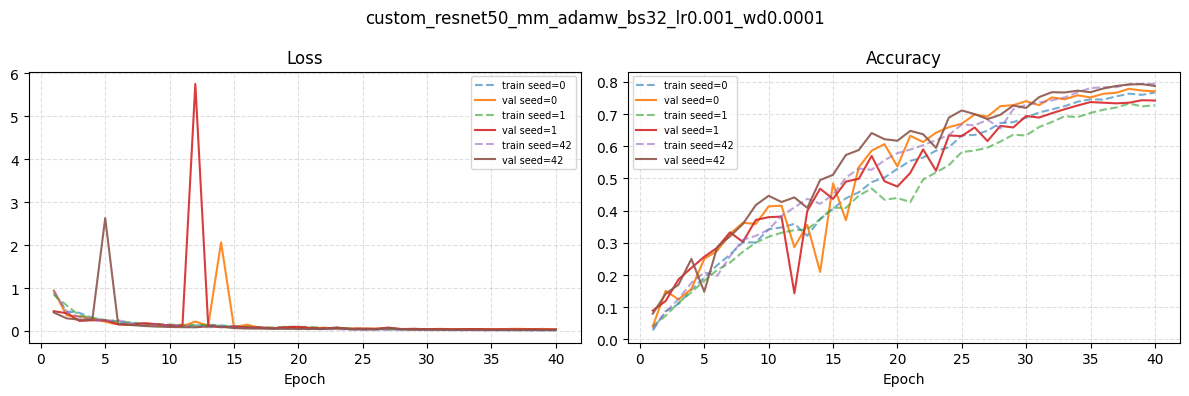

Saved: ../checkpoints_ResNets/figures/custom_resnet50_mm_adamw_bs32_lr0.001_wd0.0001_curves.png


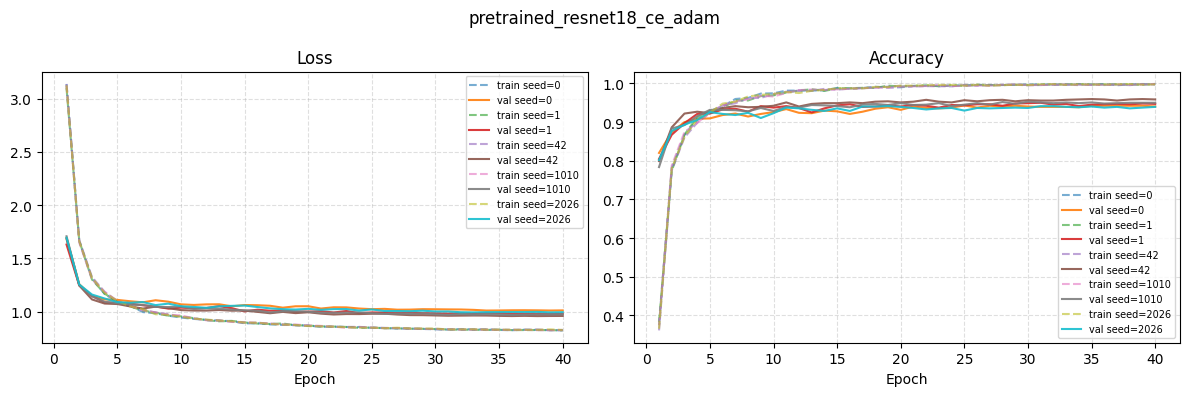

Saved: ../checkpoints_ResNets/figures/pretrained_resnet18_ce_adam_curves.png


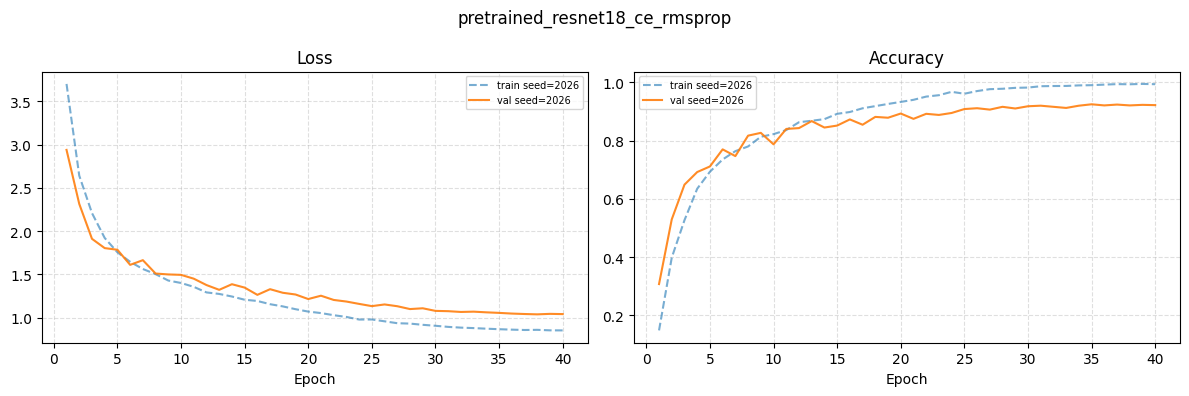

Saved: ../checkpoints_ResNets/figures/pretrained_resnet18_ce_rmsprop_curves.png


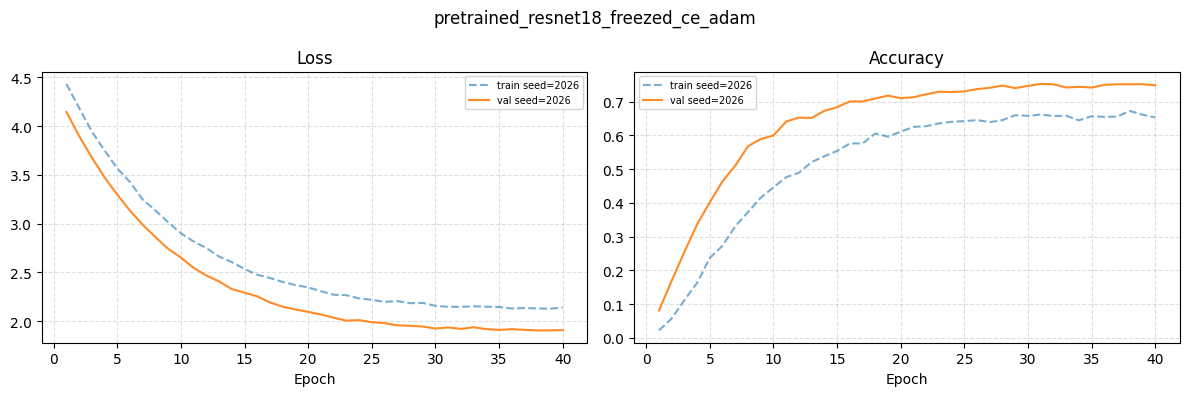

Saved: ../checkpoints_ResNets/figures/pretrained_resnet18_freezed_ce_adam_curves.png


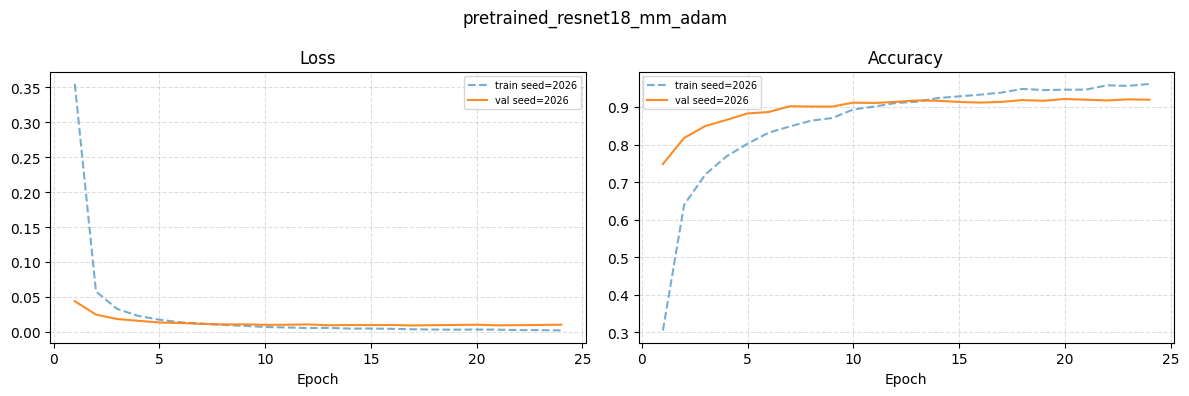

Saved: ../checkpoints_ResNets/figures/pretrained_resnet18_mm_adam_curves.png


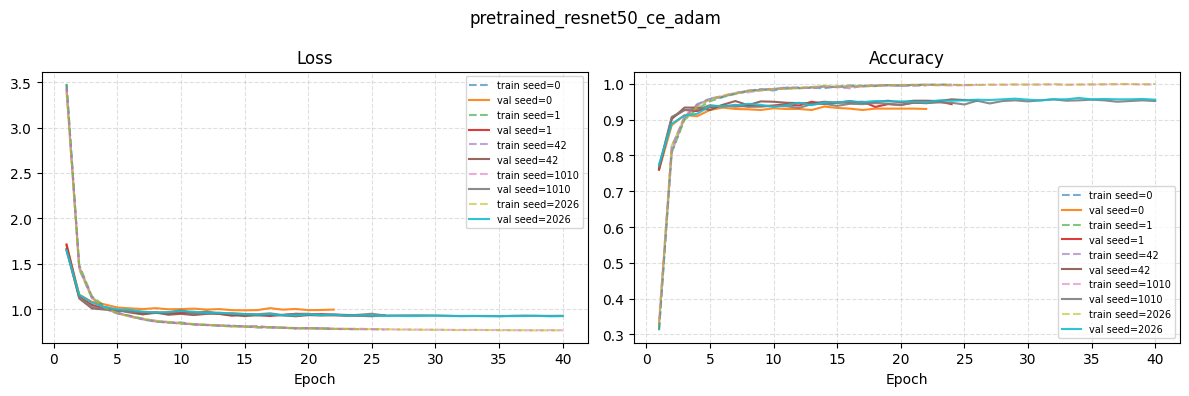

Saved: ../checkpoints_ResNets/figures/pretrained_resnet50_ce_adam_curves.png


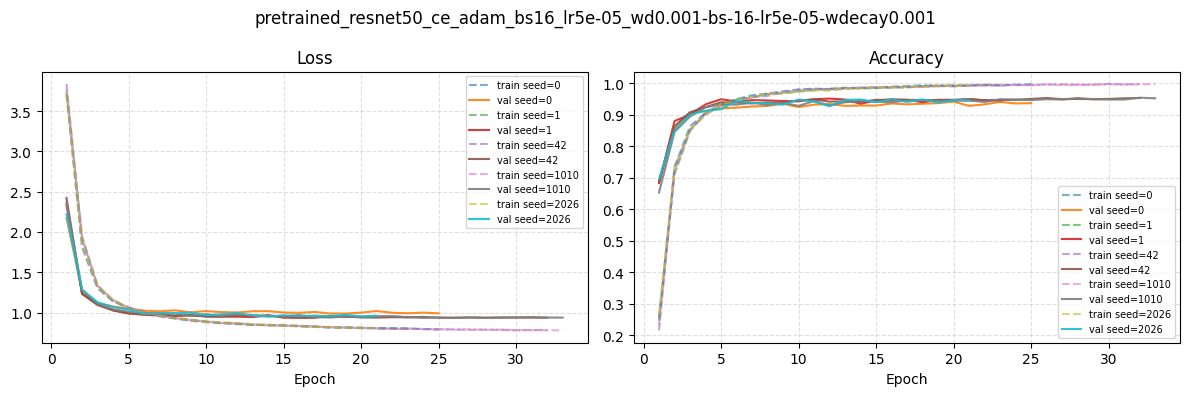

Saved: ../checkpoints_ResNets/figures/pretrained_resnet50_ce_adam_bs16_lr5e-05_wd0.001-bs-16-lr5e-05-wdecay0.001_curves.png


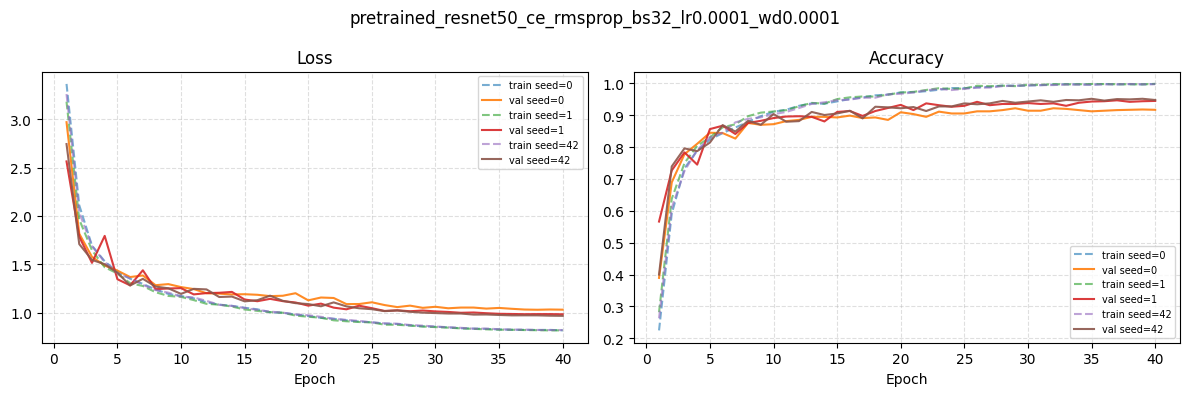

Saved: ../checkpoints_ResNets/figures/pretrained_resnet50_ce_rmsprop_bs32_lr0.0001_wd0.0001_curves.png


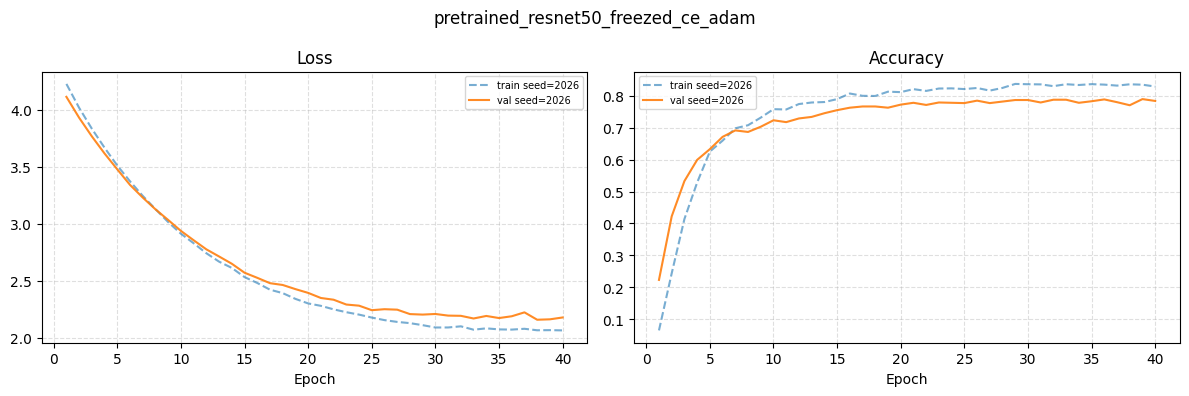

Saved: ../checkpoints_ResNets/figures/pretrained_resnet50_freezed_ce_adam_curves.png


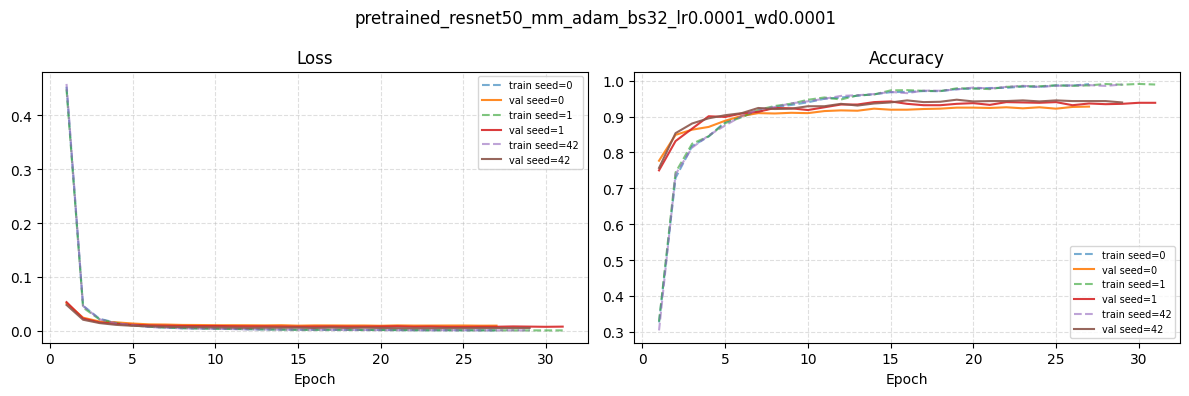

Saved: ../checkpoints_ResNets/figures/pretrained_resnet50_mm_adam_bs32_lr0.0001_wd0.0001_curves.png


In [16]:
figures_dir = CHECKPOINTS_ROOT / "figures"
figures_dir.mkdir(exist_ok=True)

for run_name, seed_dict in sorted(records.items()):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(run_name, fontsize=12)

    for seed, ckpt_data in sorted(seed_dict.items()):
        history = ckpt_data["history"]
        epochs  = range(1, len(history["train_loss"]) + 1)
        label   = f"seed={seed}"

        axes[0].plot(epochs, history["train_loss"], linestyle="--", alpha=0.6, label=f"train {label}")
        axes[0].plot(epochs, history["val_loss"],   linestyle="-",  alpha=0.9, label=f"val {label}")
        axes[1].plot(epochs, history["train_acc"],  linestyle="--", alpha=0.6, label=f"train {label}")
        axes[1].plot(epochs, history["val_acc"],    linestyle="-",  alpha=0.9, label=f"val {label}")

    for ax, title in zip(axes, ["Loss", "Accuracy"]):
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend(fontsize=7)
        ax.grid(linestyle="--", alpha=0.4)

    plt.tight_layout()
    out_path = figures_dir / f"{run_name}_curves.png"
    plt.show()
    plt.close()
    print(f"Saved: {out_path}")
